# Experiment summary by model and loss function

This notebook discovers experiment results under `outputs/experiments`, combines the five-fold cross-validation summaries, and compares every model/loss combination. Bars show fold means and error bars show one standard deviation.

In [19]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

EXPERIMENT_DIR = Path("outputs/experiments")
FIGURE_DIR = Path("outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

model_labels = {
    "af_bmau_net": "AF-BMAU-Net",
    "resunet": "ResUNet",
    "unet": "U-Net",
    "unetpp": "U-Net++",
}
loss_labels = {
    "boundary": "Boundary",
    "dice": "Dice",
    "focal": "Focal",
    "hybrid": "Hybrid",
}
run_pattern = re.compile(
    r"^run_(af_bmau_net|resunet|unetpp|unet)_(boundary|dice|focal|hybrid)_"
)

In [20]:
records = []
for run_dir in sorted(EXPERIMENT_DIR.glob("run_*")):
    match = run_pattern.match(run_dir.name)
    if not match:
        continue
    model_key, loss_key = match.groups()
    summary_files = list((run_dir / "results").glob("*/cross_validation_summary.csv"))
    if len(summary_files) != 1:
        print(f"Skipping {run_dir.name}: expected one summary, found {len(summary_files)}")
        continue

    summary = pd.read_csv(summary_files[0], index_col=0)
    record = {"model": model_labels[model_key], "loss": loss_labels[loss_key]}
    for metric, values in summary.iterrows():
        record[f"{metric}_mean"] = values["mean"]
        record[f"{metric}_std"] = values["std"]
    records.append(record)

results = pd.DataFrame(records)
model_order = list(model_labels.values())
loss_order = list(loss_labels.values())
results["model"] = pd.Categorical(results["model"], model_order, ordered=True)
results["loss"] = pd.Categorical(results["loss"], loss_order, ordered=True)
results = results.sort_values(["model", "loss"]).reset_index(drop=True)

expected = len(model_order) * len(loss_order)
if len(results) != expected:
    print(f"Warning: loaded {len(results)} of {expected} expected model/loss combinations.")

display(results)

,model,loss,dice_mean,dice_std,iou_mean,iou_std,precision_mean,precision_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,hd95_mean,hd95_std,pred_dvp_px_mean,pred_dvp_px_std
0,AF-BMAU-Net,Boundary,0.0837,0.0960,0.0465,0.0557,0.4034,0.4469,0.6001,0.4901,0.4008,0.4849,140.5120,18.5452,182.5625,144.5541
1,AF-BMAU-Net,Dice,0.9719,0.0256,0.9463,0.0441,0.9763,0.0122,0.9682,0.0405,0.9983,0.0012,2.2631,4.1217,106.0139,31.1471
2,AF-BMAU-Net,Focal,0.9642,0.0324,0.9326,0.0553,0.9908,0.0073,0.9404,0.0535,0.9994,0.0004,2.9378,5.0643,104.0750,31.4378
3,AF-BMAU-Net,Hybrid,0.9732,0.0215,0.9486,0.0376,0.9768,0.0133,0.9702,0.0324,0.9984,0.0009,1.8720,3.2448,106.1958,30.9419
4,ResUNet,Boundary,0.1403,0.0869,0.0779,0.0527,0.0779,0.0527,0.9990,0.0082,0.0057,0.0170,142.1438,15.2318,300.0000,0.0000
5,ResUNet,Dice,0.9682,0.0222,0.9392,0.0383,0.9723,0.0109,0.9648,0.0360,0.9978,0.0019,2.5330,3.8409,105.7611,31.1154
6,ResUNet,Focal,0.9629,0.0323,0.9303,0.0553,0.9900,0.0065,0.9388,0.0535,0.9994,0.0004,3.0919,5.1019,104.1153,31.3043
7,ResUNet,Hybrid,0.9710,0.0241,0.9446,0.0415,0.9772,0.0108,0.9656,0.0388,0.9984,0.0011,2.2415,3.8045,105.8028,31.0231
8,U-Net,Boundary,0.1282,0.1278,0.0738,0.0787,0.3116,0.3775,0.5110,0.4408,0.5684,0.4555,107.4120,39.7733,165.2861,123.6137
9,U-Net,Dice,0.9666,0.0193,0.9360,0.0342,0.9526,0.0252,0.9815,0.0206,0.9966,0.0021,2.1532,1.9280,107.5750,30.6511


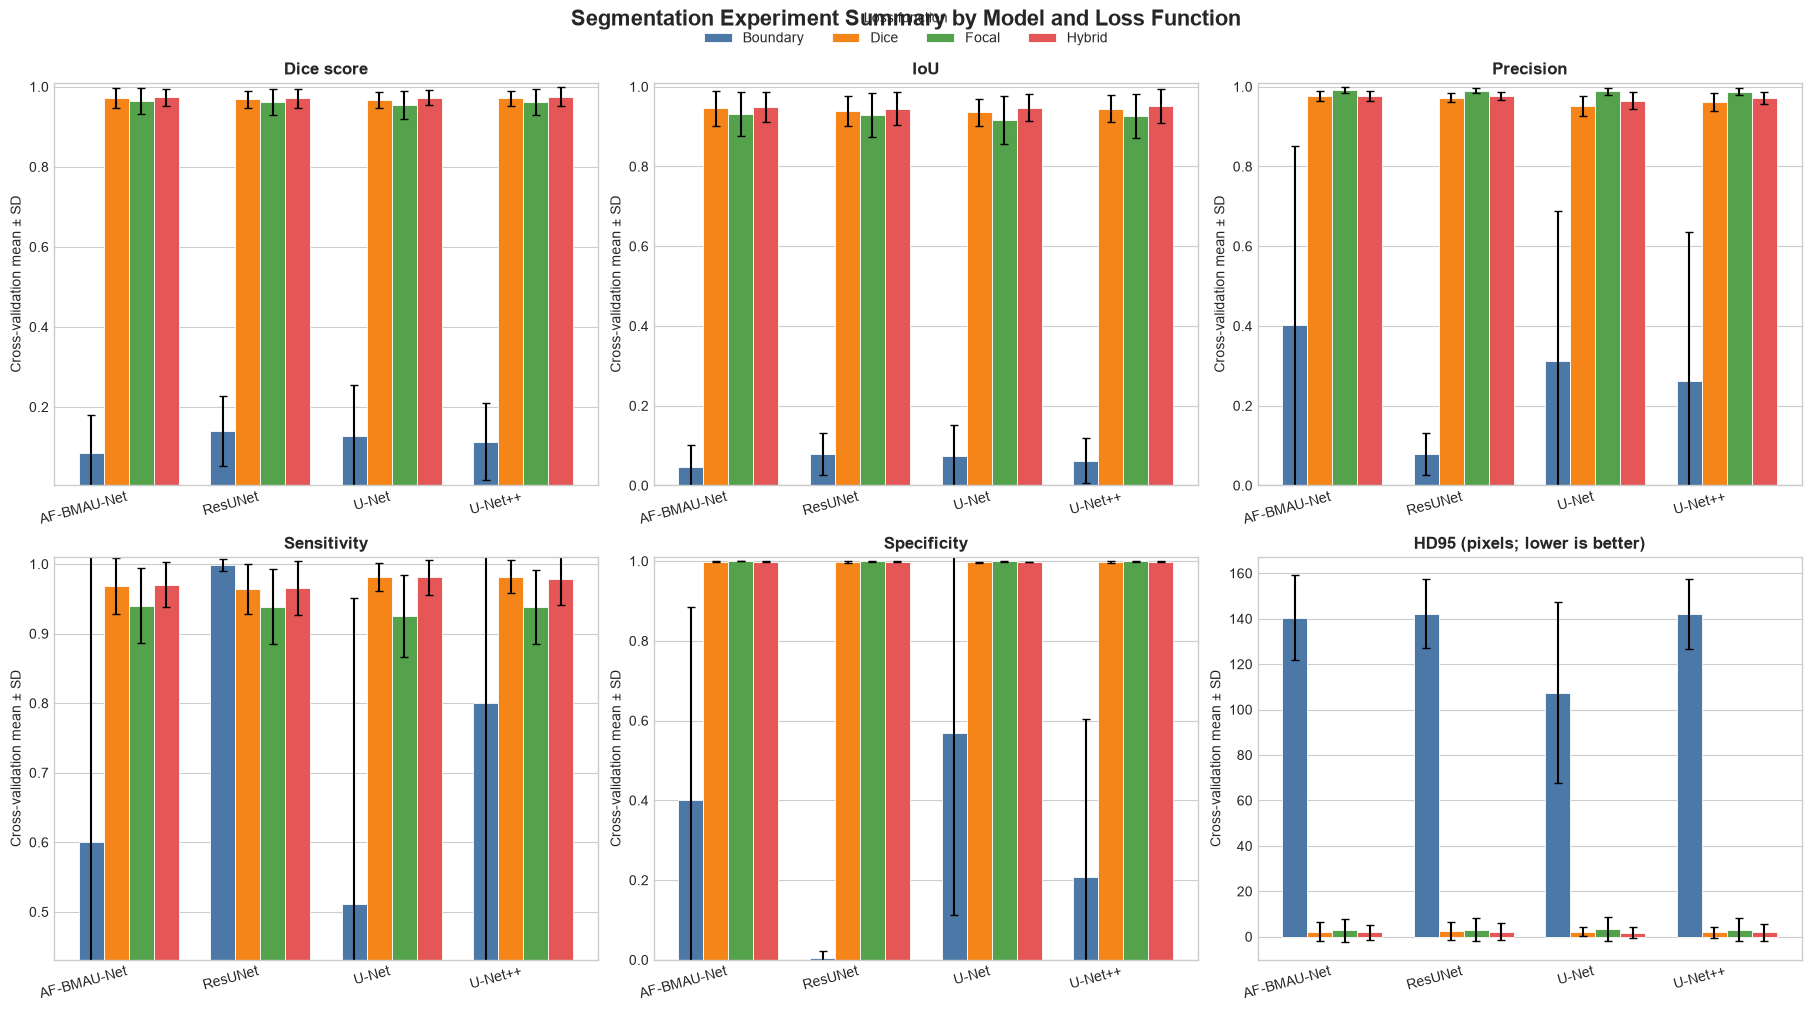

Saved figure to outputs\figures\experiment_summary_by_model_and_loss.png


In [21]:
metrics = ["dice", "iou", "precision", "sensitivity", "specificity", "hd95"]
metric_labels = {
    "dice": "Dice score",
    "iou": "IoU",
    "precision": "Precision",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "hd95": "HD95 (pixels; lower is better)",
}
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
x = np.arange(len(model_order))
width = 0.19

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, metric in zip(axes.flat, metrics):
    for loss_index, (loss, color) in enumerate(zip(loss_order, colors)):
        subset = results[results["loss"] == loss].set_index("model").reindex(model_order)
        positions = x + (loss_index - (len(loss_order) - 1) / 2) * width
        ax.bar(
            positions, subset[f"{metric}_mean"], width,
            yerr=subset[f"{metric}_std"], capsize=3,
            label=loss, color=color, edgecolor="white", linewidth=0.6,
        )
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_xticks(x, model_order, rotation=15, ha="right")
    ax.set_ylabel("Cross-validation mean ± SD")
    ax.grid(axis="x", visible=False)
    if metric != "hd95":
        lower = max(0, results[f"{metric}_mean"].min() - 0.08)
        ax.set_ylim(lower, 1.01)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Loss function", loc="outside upper center", ncol=4)
fig.suptitle("Segmentation Experiment Summary by Model and Loss Function", fontsize=16, fontweight="bold")
figure_path = FIGURE_DIR / "experiment_summary_by_model_and_loss.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure to {figure_path}")

In [22]:
# Best model/loss combination for each metric.
best_rows = []
for metric in metrics:
    idx = results[f"{metric}_mean"].idxmin() if metric == "hd95" else results[f"{metric}_mean"].idxmax()
    row = results.loc[idx]
    best_rows.append({
        "metric": metric_labels[metric],
        "model": row["model"],
        "loss": row["loss"],
        "mean": row[f"{metric}_mean"],
        "std": row[f"{metric}_std"],
    })
best_results = pd.DataFrame(best_rows)
display(best_results)

,metric,model,loss,mean,std
0,Dice score,U-Net++,Hybrid,0.9747,0.0240
1,IoU,U-Net++,Hybrid,0.9517,0.0415
2,Precision,AF-BMAU-Net,Focal,0.9908,0.0073
3,Sensitivity,ResUNet,Boundary,0.9990,0.0082
4,Specificity,AF-BMAU-Net,Focal,0.9994,0.0004
5,HD95 (pixels; lower is better),U-Net,Hybrid,1.7621,2.5120


## Visual comparison against ground truth

Each row compares the same test image against the ground-truth mask and predictions from all four models. Change `SELECTED_LOSS` or `SAMPLE_IDS` to inspect other experiments and images. Dice and IoU are calculated directly from the saved binary predictions.

In [23]:
from PIL import Image

SELECTED_LOSS = "hybrid"  # boundary, dice, focal, or hybrid
SAMPLE_IDS = ["CEO003", "CEO032", "CEO070"]

def load_binary_mask(path, size=None):
    image = Image.open(path).convert("L")
    if size is not None:
        image = image.resize(size, Image.Resampling.NEAREST)
    return np.asarray(image) > 127

def segmentation_scores(ground_truth, prediction):
    intersection = np.logical_and(ground_truth, prediction).sum()
    gt_area, pred_area = ground_truth.sum(), prediction.sum()
    union = np.logical_or(ground_truth, prediction).sum()
    dice = (2 * intersection) / (gt_area + pred_area) if gt_area + pred_area else 1.0
    iou = intersection / union if union else 1.0
    return dice, iou

def prediction_path(model_key, loss_key, sample_id):
    runs = sorted(EXPERIMENT_DIR.glob(f"run_{model_key}_{loss_key}_*"))
    if not runs:
        raise FileNotFoundError(f"No experiment found for {model_key}/{loss_key}")
    matches = list((runs[-1] / "predictions").rglob(f"{sample_id}_pred.png"))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one prediction for {sample_id} in {runs[-1].name}; found {len(matches)}"
        )
    return matches[0]

model_keys = ["af_bmau_net", "resunet", "unet", "unetpp"]

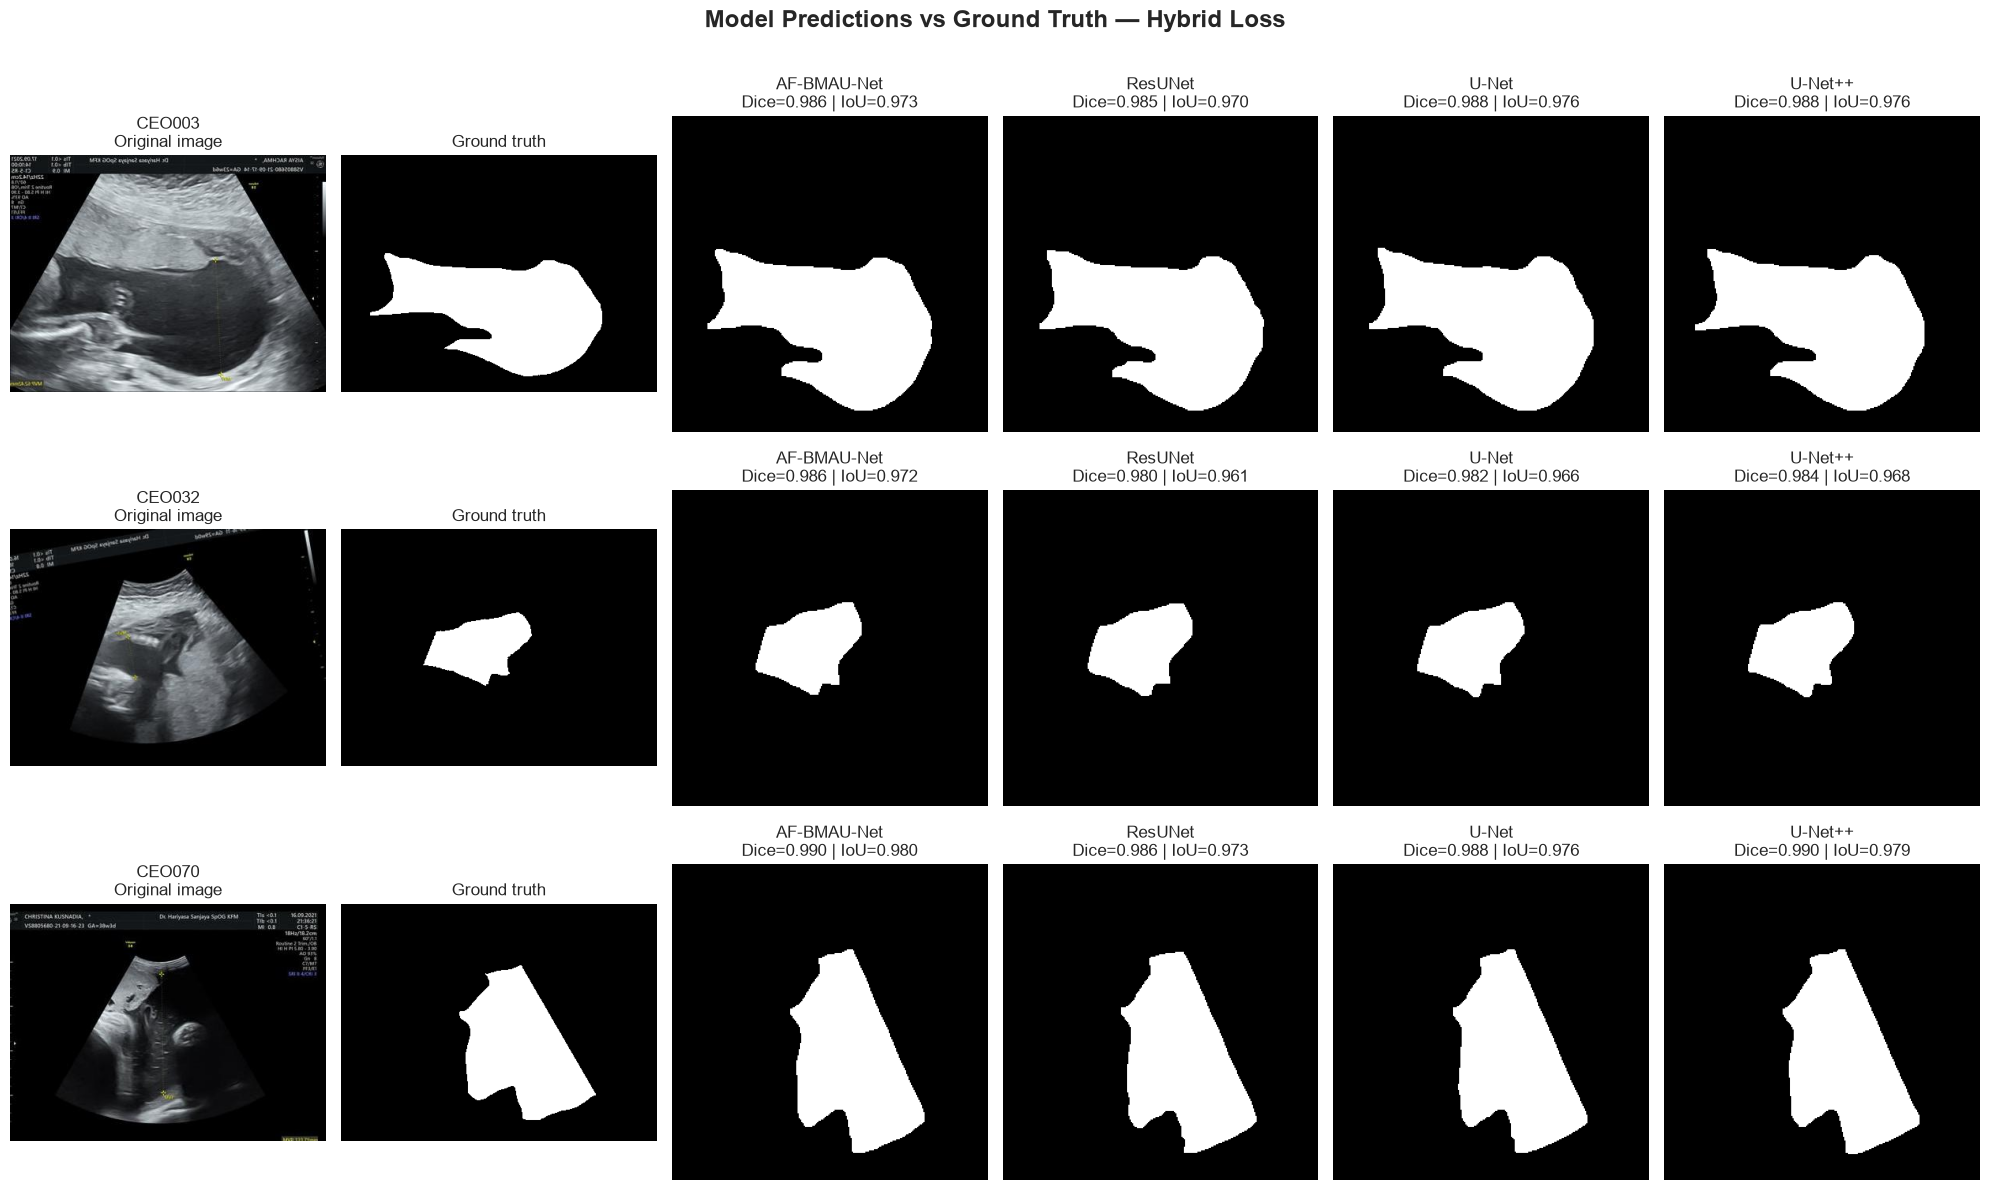

dice                     iou                
sample       CEO003  CEO032  CEO070  CEO003  CEO032  CEO070
model                                                      
AF-BMAU-Net  0.9864  0.9860  0.9900  0.9732  0.9725  0.9803
ResUNet      0.9846  0.9801  0.9862  0.9696  0.9610  0.9728
U-Net        0.9880  0.9825  0.9878  0.9764  0.9656  0.9758
U-Net++      0.9881  0.9836  0.9895  0.9764  0.9677  0.9793

Saved comparison to outputs\figures\model_vs_ground_truth_hybrid.png


In [24]:
fig, axes = plt.subplots(len(SAMPLE_IDS), 6, figsize=(20, 4 * len(SAMPLE_IDS)), squeeze=False)
score_records = []

for row, sample_id in enumerate(SAMPLE_IDS):
    image_path = Path("data/images") / f"{sample_id}.jpg"
    gt_path = Path("data/masks") / f"{sample_id}_mask.png"
    original = np.asarray(Image.open(image_path).convert("RGB"))
    gt_original = load_binary_mask(gt_path)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"{sample_id}\nOriginal image")
    axes[row, 1].imshow(gt_original, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("Ground truth")

    for column, model_key in enumerate(model_keys, start=2):
        pred_path = prediction_path(model_key, SELECTED_LOSS, sample_id)
        prediction = load_binary_mask(pred_path)
        gt_resized = load_binary_mask(gt_path, size=(prediction.shape[1], prediction.shape[0]))
        dice, iou = segmentation_scores(gt_resized, prediction)
        score_records.append({
            "sample": sample_id, "model": model_labels[model_key],
            "loss": loss_labels[SELECTED_LOSS], "dice": dice, "iou": iou,
        })
        axes[row, column].imshow(prediction, cmap="gray", vmin=0, vmax=1)
        axes[row, column].set_title(
            f"{model_labels[model_key]}\nDice={dice:.3f} | IoU={iou:.3f}"
        )

    for ax in axes[row]:
        ax.axis("off")

fig.suptitle(
    f"Model Predictions vs Ground Truth — {loss_labels[SELECTED_LOSS]} Loss",
    fontsize=17, fontweight="bold", y=1.01,
)
fig.tight_layout()
comparison_path = FIGURE_DIR / f"model_vs_ground_truth_{SELECTED_LOSS}.png"
fig.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

sample_scores = pd.DataFrame(score_records)
display(sample_scores.pivot(index="model", columns="sample", values=["dice", "iou"]))
print(f"Saved comparison to {comparison_path}")

## Boundary/contour comparison

This view makes small shape differences easier to see than filled masks. In each model panel, the ground-truth boundary is green and dashed, while the predicted boundary is red and solid. The final panel overlays all model boundaries using distinct colors.

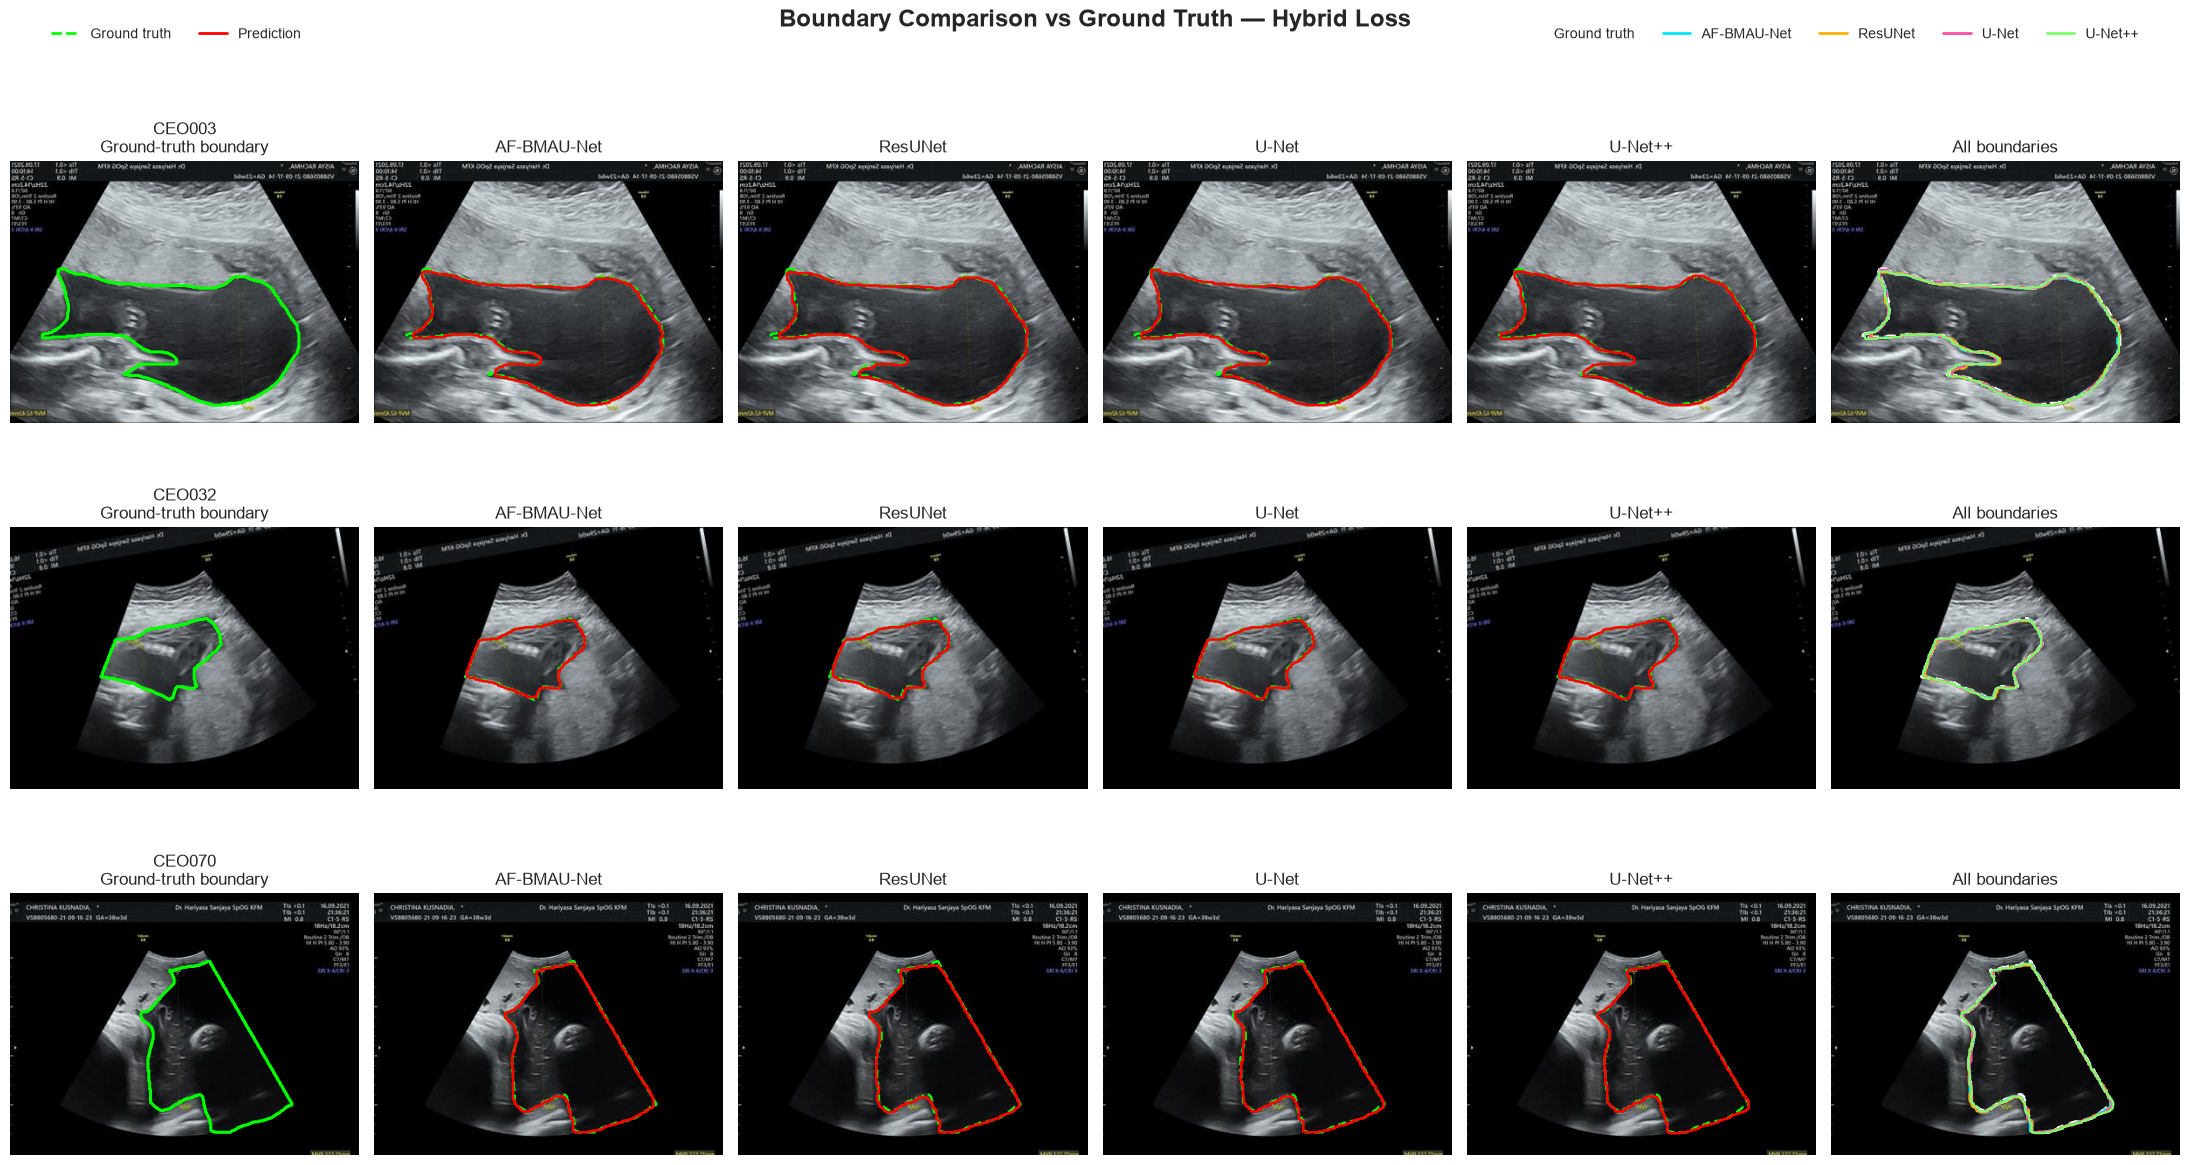

Saved boundary comparison to outputs\figures\model_boundary_vs_ground_truth_hybrid.png


In [25]:
from matplotlib.lines import Line2D

model_colors = {
    "af_bmau_net": "#00E5FF",
    "resunet": "#FFB000",
    "unet": "#FF4FA3",
    "unetpp": "#7CFF6B",
}

fig, axes = plt.subplots(len(SAMPLE_IDS), 6, figsize=(22, 4 * len(SAMPLE_IDS)), squeeze=False)
for row, sample_id in enumerate(SAMPLE_IDS):
    image_path = Path("data/images") / f"{sample_id}.jpg"
    gt_path = Path("data/masks") / f"{sample_id}_mask.png"
    original = np.asarray(Image.open(image_path).convert("RGB"))
    target_size = (original.shape[1], original.shape[0])
    ground_truth = load_binary_mask(gt_path, size=target_size)

    # Ground-truth reference panel.
    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].contour(ground_truth, levels=[0.5], colors=["lime"], linewidths=2.2)
    axes[row, 0].set_title(f"{sample_id}\nGround-truth boundary")

    resized_predictions = {}
    for column, model_key in enumerate(model_keys, start=1):
        pred_path = prediction_path(model_key, SELECTED_LOSS, sample_id)
        prediction = load_binary_mask(pred_path, size=target_size)
        resized_predictions[model_key] = prediction
        ax = axes[row, column]
        ax.imshow(original, cmap="gray")
        ax.contour(ground_truth, levels=[0.5], colors=["lime"], linewidths=1.8, linestyles="--")
        ax.contour(prediction, levels=[0.5], colors=["red"], linewidths=1.8)
        ax.set_title(model_labels[model_key])

    # One combined view for direct model-to-model boundary comparison.
    combined_ax = axes[row, 5]
    combined_ax.imshow(original, cmap="gray")
    combined_ax.contour(ground_truth, levels=[0.5], colors=["white"], linewidths=2.3, linestyles="--")
    for model_key, prediction in resized_predictions.items():
        combined_ax.contour(
            prediction, levels=[0.5], colors=[model_colors[model_key]], linewidths=1.5
        )
    combined_ax.set_title("All boundaries")

    for ax in axes[row]:
        ax.axis("off")

panel_legend = [
    Line2D([0], [0], color="lime", linestyle="--", lw=2, label="Ground truth"),
    Line2D([0], [0], color="red", lw=2, label="Prediction"),
]
combined_legend = [Line2D([0], [0], color="white", linestyle="--", lw=2, label="Ground truth")]
combined_legend += [
    Line2D([0], [0], color=model_colors[key], lw=2, label=model_labels[key]) for key in model_keys
]
fig.legend(handles=panel_legend, loc="outside upper left", bbox_to_anchor=(0.02, 1.02), ncol=2)
fig.legend(handles=combined_legend, loc="outside upper right", bbox_to_anchor=(0.98, 1.02), ncol=5)
fig.suptitle(
    f"Boundary Comparison vs Ground Truth — {loss_labels[SELECTED_LOSS]} Loss",
    fontsize=17, fontweight="bold", y=1.025,
)
fig.tight_layout()
boundary_path = FIGURE_DIR / f"model_boundary_vs_ground_truth_{SELECTED_LOSS}.png"
fig.savefig(boundary_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved boundary comparison to {boundary_path}")

## Deepest Vertical Pocket (DVP) comparison

This section searches all test images under the selected loss and selects the **best-case AF-BMAU-Net example**: AF-BMAU-Net must have the lowest absolute DVP error and the largest advantage over the next-best model. The selection is explicitly best-case, not an unbiased estimate of overall performance. Measurements are reported in pixels because the experiment outputs contain no pixel-to-millimetre calibration.

In [26]:
# DVP comparison version 2: selects a clean, continuous vertical path.
# Reload this notebook from disk if this cell is not visible in the editor.
def deepest_vertical_pocket(mask):
    best = {"length_px": 0, "x": None, "y_top": None, "y_bottom": None}
    for x in range(mask.shape[1]):
        rows = np.flatnonzero(mask[:, x])
        if rows.size:
            length = int(rows[-1] - rows[0] + 1)
            if length > best["length_px"]:
                best = {"length_px": length, "x": int(x), "y_top": int(rows[0]), "y_bottom": int(rows[-1])}
    return best

dvp_frames = []
for model_key in model_keys:
    run_dir = sorted(EXPERIMENT_DIR.glob(f"run_{model_key}_{SELECTED_LOSS}_*"))[-1]
    result_file = list((run_dir / "results").glob("*/cross_validation_results.csv"))[0]
    frame = pd.read_csv(result_file)[["filename", "pred_dvp_px"]].copy()
    frame["model_key"] = model_key
    frame["model"] = model_labels[model_key]
    dvp_frames.append(frame)

dvp_results = pd.concat(dvp_frames, ignore_index=True)
gt_values = {}
for filename in dvp_results["filename"].unique():
    gt_path = Path("data/masks") / f"{Path(filename).stem}_mask.png"
    gt_values[filename] = deepest_vertical_pocket(load_binary_mask(gt_path))["length_px"]
dvp_results["gt_dvp_px"] = dvp_results["filename"].map(gt_values)
dvp_results["absolute_error_px"] = (dvp_results["pred_dvp_px"] - dvp_results["gt_dvp_px"]).abs()

error_matrix = dvp_results.pivot(index="filename", columns="model", values="absolute_error_px")
competitors = [model for model in model_order if model != "AF-BMAU-Net"]
error_matrix["af_advantage_px"] = error_matrix[competitors].min(axis=1) - error_matrix["AF-BMAU-Net"]
eligible = error_matrix[error_matrix["af_advantage_px"] > 0]
if eligible.empty:
    raise ValueError("AF-BMAU-Net is not uniquely best on any image.")

def has_clean_dvp_path(mask, side_clearance=2, minimum_interior_ratio=0.90):
    # Reject a DVP line that bridges separated foreground regions or runs along a boundary.
    line = deepest_vertical_pocket(mask)
    if line["x"] is None or line["length_px"] < 2:
        return False
    x, y0, y1 = line["x"], line["y_top"], line["y_bottom"]
    if not mask[y0:y1 + 1, x].all():
        return False  # The vertical line would cross a gap between mask components.
    left, right = max(0, x - side_clearance), min(mask.shape[1], x + side_clearance + 1)
    interior = mask[y0 + 1:y1, left:right]
    return interior.size > 0 and interior.mean() >= minimum_interior_ratio

# Search in performance order, then retain the first image whose GT and all predicted
# DVP lines pass through a continuous mask interior without cutting across a gap/contour.
selected_filename = None
ordered_candidates = eligible.sort_values(["af_advantage_px", "AF-BMAU-Net"], ascending=[False, True]).index
for candidate in ordered_candidates:
    candidate_id = Path(candidate).stem
    candidate_image = Image.open(Path("data/images") / candidate)
    candidate_size = candidate_image.size
    masks_to_check = [
        load_binary_mask(Path("data/masks") / f"{candidate_id}_mask.png", size=candidate_size)
    ]
    masks_to_check += [
        load_binary_mask(prediction_path(key, SELECTED_LOSS, candidate_id), size=candidate_size)
        for key in model_keys
    ]
    if all(has_clean_dvp_path(mask) for mask in masks_to_check):
        selected_filename = candidate
        break
if selected_filename is None:
    raise ValueError("No image satisfies both AF-BMAU-Net superiority and a clean DVP path.")
selected_id = Path(selected_filename).stem
selected_dvp = dvp_results[dvp_results["filename"] == selected_filename].copy()
selected_dvp["rank"] = selected_dvp["absolute_error_px"].rank(method="min").astype(int)
selected_dvp = selected_dvp.sort_values(["rank", "model"])
print(f"Selected best-case AF-BMAU-Net image: {selected_filename}")
display(selected_dvp[["rank", "model", "gt_dvp_px", "pred_dvp_px", "absolute_error_px"]])

Selected best-case AF-BMAU-Net image: CEO257.jpg


,rank,model,gt_dvp_px,pred_dvp_px,absolute_error_px
196,1,AF-BMAU-Net,119,119,0
2356,2,U-Net++,119,117,2
1636,3,U-Net,119,116,3
916,4,ResUNet,119,115,4


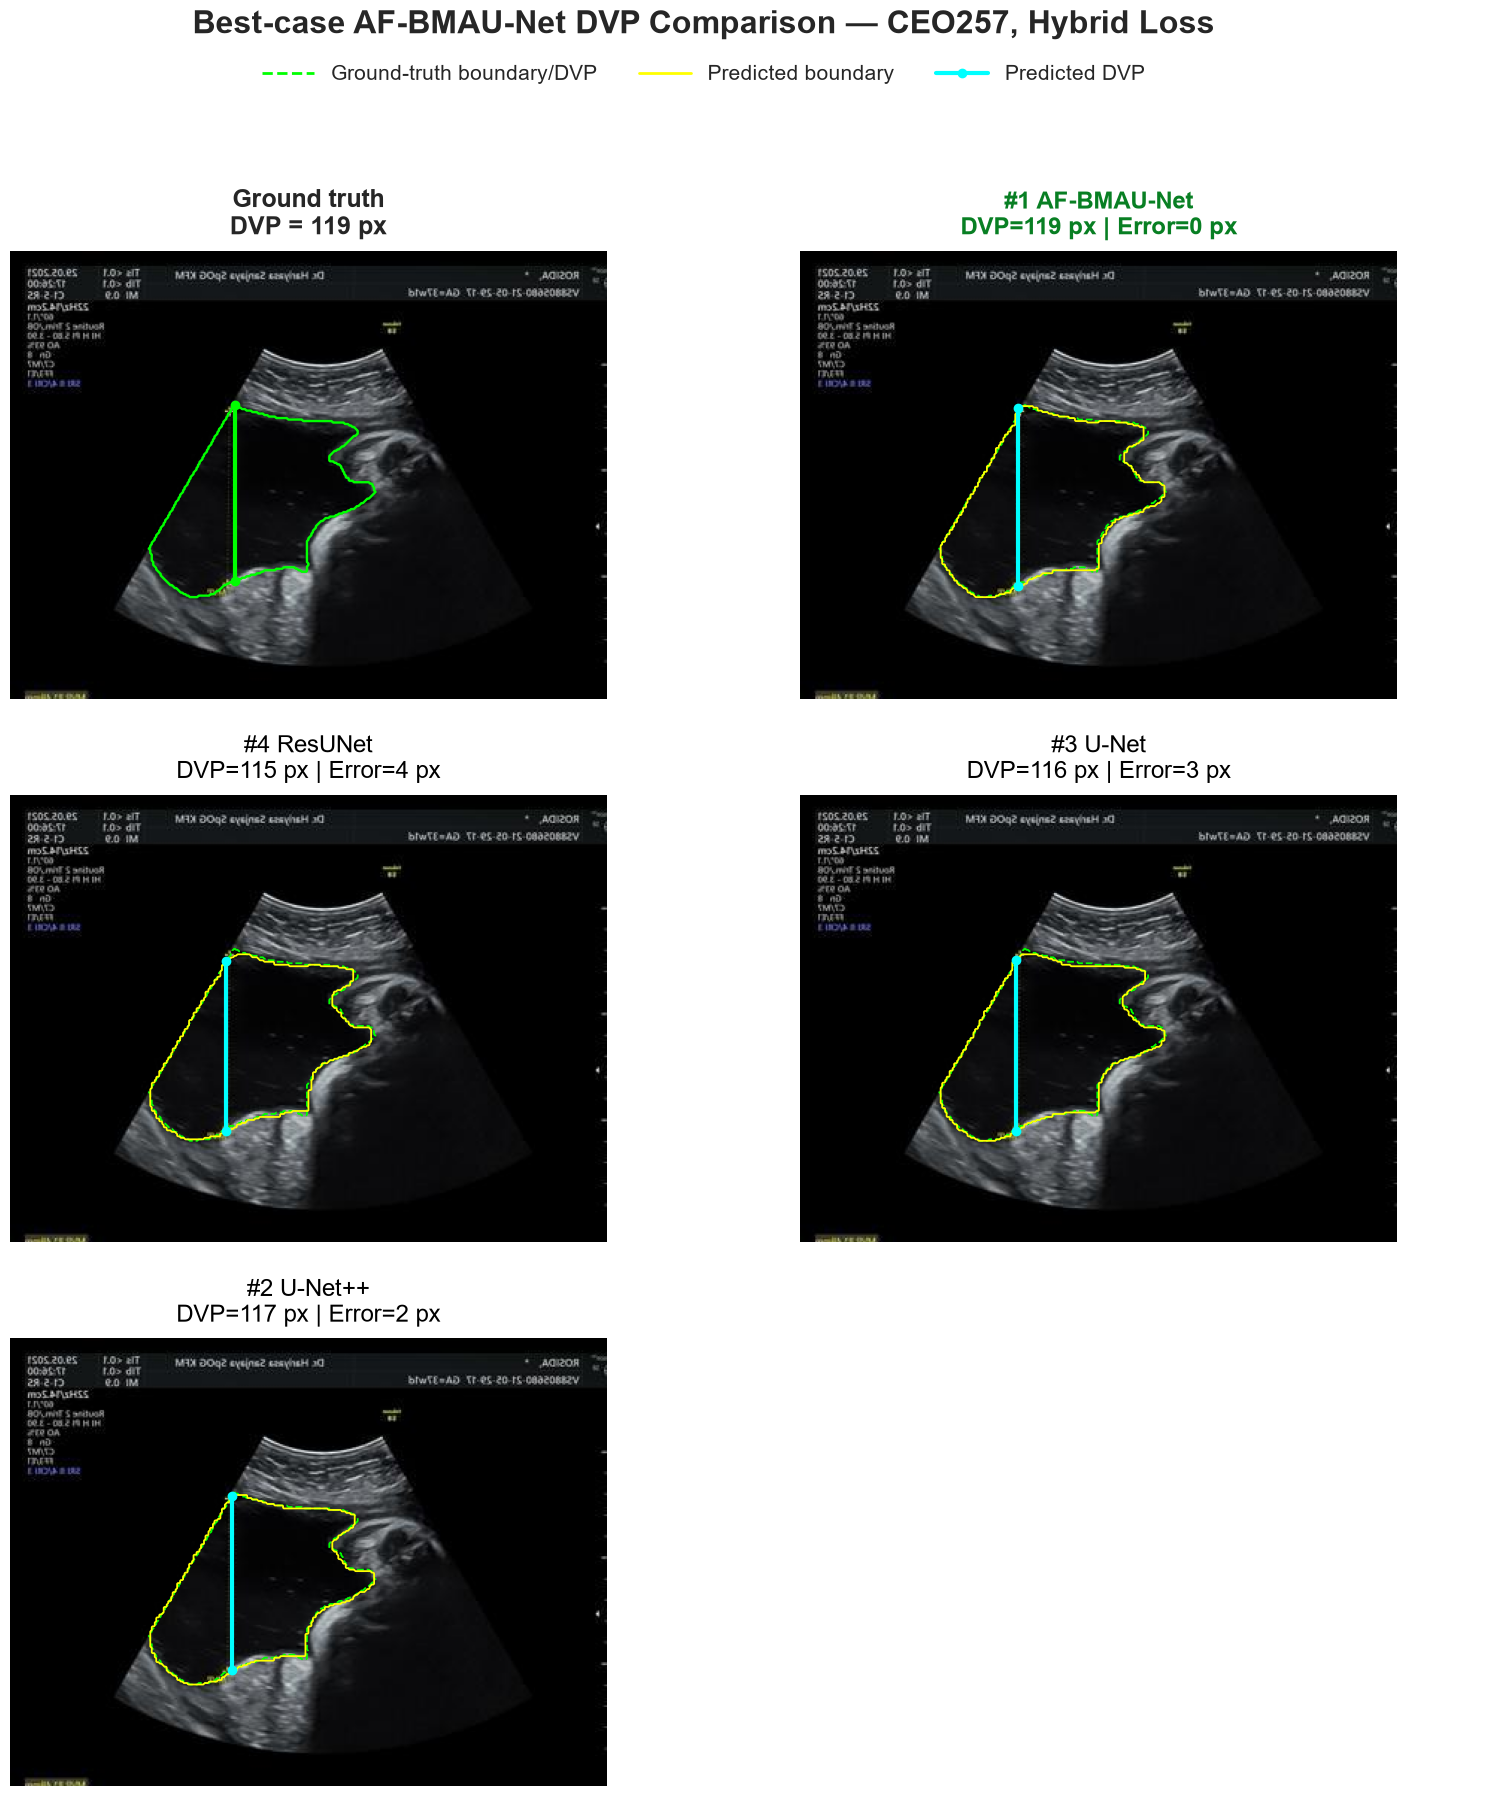

Saved DVP comparison to outputs\figures\dvp_best_af_bmau_net_hybrid.png


In [27]:
original = np.asarray(Image.open(Path("data/images") / selected_filename).convert("RGB"))
target_size = (original.shape[1], original.shape[0])
gt_mask = load_binary_mask(Path("data/masks") / f"{selected_id}_mask.png", size=target_size)
gt_line = deepest_vertical_pocket(gt_mask)

# Two-column layout keeps panels large while avoiding an excessively tall figure.
fig, axes_grid = plt.subplots(3, 2, figsize=(16, 18))
axes = axes_grid.ravel()
axes[0].imshow(original)
axes[0].contour(gt_mask, levels=[0.5], colors=["lime"], linewidths=1.7)
axes[0].plot([gt_line["x"]] * 2, [gt_line["y_top"], gt_line["y_bottom"]], color="lime", lw=3, marker="o")
axes[0].set_title(f"Ground truth\nDVP = {gt_line['length_px']} px", fontsize=18, fontweight="bold", pad=12)

for ax, model_key in zip(axes[1:], model_keys):
    row = selected_dvp[selected_dvp["model_key"] == model_key].iloc[0]
    prediction = load_binary_mask(prediction_path(model_key, SELECTED_LOSS, selected_id), size=target_size)
    pred_line = deepest_vertical_pocket(prediction)
    ax.imshow(original)
    ax.contour(gt_mask, levels=[0.5], colors=["lime"], linewidths=1.3, linestyles="--")
    ax.contour(prediction, levels=[0.5], colors=["yellow"], linewidths=1.3)
    ax.plot([pred_line["x"]] * 2, [pred_line["y_top"], pred_line["y_bottom"]], color="cyan", lw=3, marker="o")
    is_best = int(row["rank"]) == 1
    ax.set_title(
        f"#{int(row['rank'])} {model_labels[model_key]}\nDVP={int(row['pred_dvp_px'])} px | Error={int(row['absolute_error_px'])} px",
        color="#087F23" if is_best else "black", fontsize=17,
        fontweight="bold" if is_best else "normal", pad=12,
    )

for ax in axes[:5]:
    ax.axis("off")
axes[5].axis("off")  # Unused slot in the 3 x 2 grid.
dvp_legend = [
    Line2D([0], [0], color="lime", linestyle="--", lw=2, label="Ground-truth boundary/DVP"),
    Line2D([0], [0], color="yellow", lw=2, label="Predicted boundary"),
    Line2D([0], [0], color="cyan", lw=3, marker="o", label="Predicted DVP"),
]
fig.legend(
    handles=dvp_legend, loc="outside upper center", ncol=3,
    bbox_to_anchor=(0.5, 0.975), fontsize=15, handlelength=2.5, columnspacing=2.0,
)
fig.suptitle(
    f"Best-case AF-BMAU-Net DVP Comparison — {selected_id}, {loss_labels[SELECTED_LOSS]} Loss",
    fontsize=23, fontweight="bold", y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.93), h_pad=2.5, w_pad=1.5)
dvp_path = FIGURE_DIR / f"dvp_best_af_bmau_net_{SELECTED_LOSS}.png"
fig.savefig(dvp_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved DVP comparison to {dvp_path}")